<a href="https://colab.research.google.com/github/madhumita070507/ShadowFox/blob/Madhumita/Shadowfox(intermediate).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#datapreprocessing
import pandas as pd
#got UnicodeDecodeError
data=pd.read_csv(f"/content/sample_data/Sample - Superstore.csv", encoding='latin1')
data.head()
print(data.isnull().sum())
#seems like no missing values
print(data.duplicated().sum())

#seems like no duplicated values either
data.drop_duplicates(inplace=True)#for extra precaution


#to check how much sales actually becomes profit we add a profit margin
data['Profit Margin']=data['Profit']/data['Sales']

#finding the bestselling categories using groupby
best_selling_categories=data.groupby('Category')['Sales'].sum()
#idxmax=index of the maximum sum
print(f"best selling category: {best_selling_categories.idxmax()}")



Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64
0
best selling category: Technology


In [ ]:
print(data.describe())
##gives important statistics about the dataset[count:how many values are under this column, mean:average value of each column, std:variance of each value in the column, min:minimum value of each column, max:maximum value of each column, 25%	The value below which 25% of data falls (1st quartile, or Q1)50%	The middle value (median) — 50% of values are below this 75%	The value below which 75% of data falls (3rd quartile, or Q3)]

            Row ID   Postal Code         Sales     Quantity     Discount  \
count  9994.000000   9994.000000   9994.000000  9994.000000  9994.000000   
mean   4997.500000  55190.379428    229.858001     3.789574     0.156203   
std    2885.163629  32063.693350    623.245101     2.225110     0.206452   
min       1.000000   1040.000000      0.444000     1.000000     0.000000   
25%    2499.250000  23223.000000     17.280000     2.000000     0.000000   
50%    4997.500000  56430.500000     54.490000     3.000000     0.200000   
75%    7495.750000  90008.000000    209.940000     5.000000     0.200000   
max    9994.000000  99301.000000  22638.480000    14.000000     0.800000   

            Profit  Profit Margin  
count  9994.000000    9994.000000  
mean     28.656896       0.120314  
std     234.260108       0.466754  
min   -6599.978000      -2.750000  
25%       1.728750       0.075000  
50%       8.666500       0.270000  
75%      29.364000       0.362500  
max    8399.976000       0.

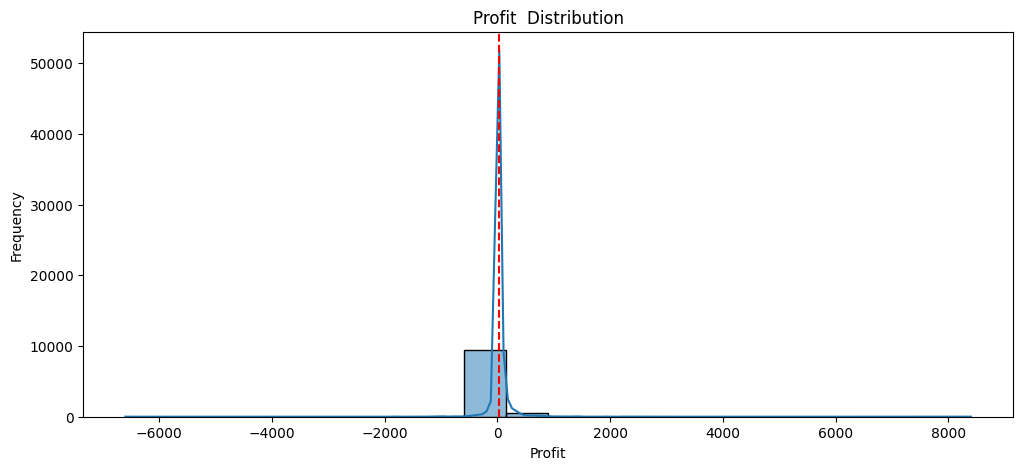

Global Super Steno Chair


/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 147 (\x93) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 148 (\x94) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


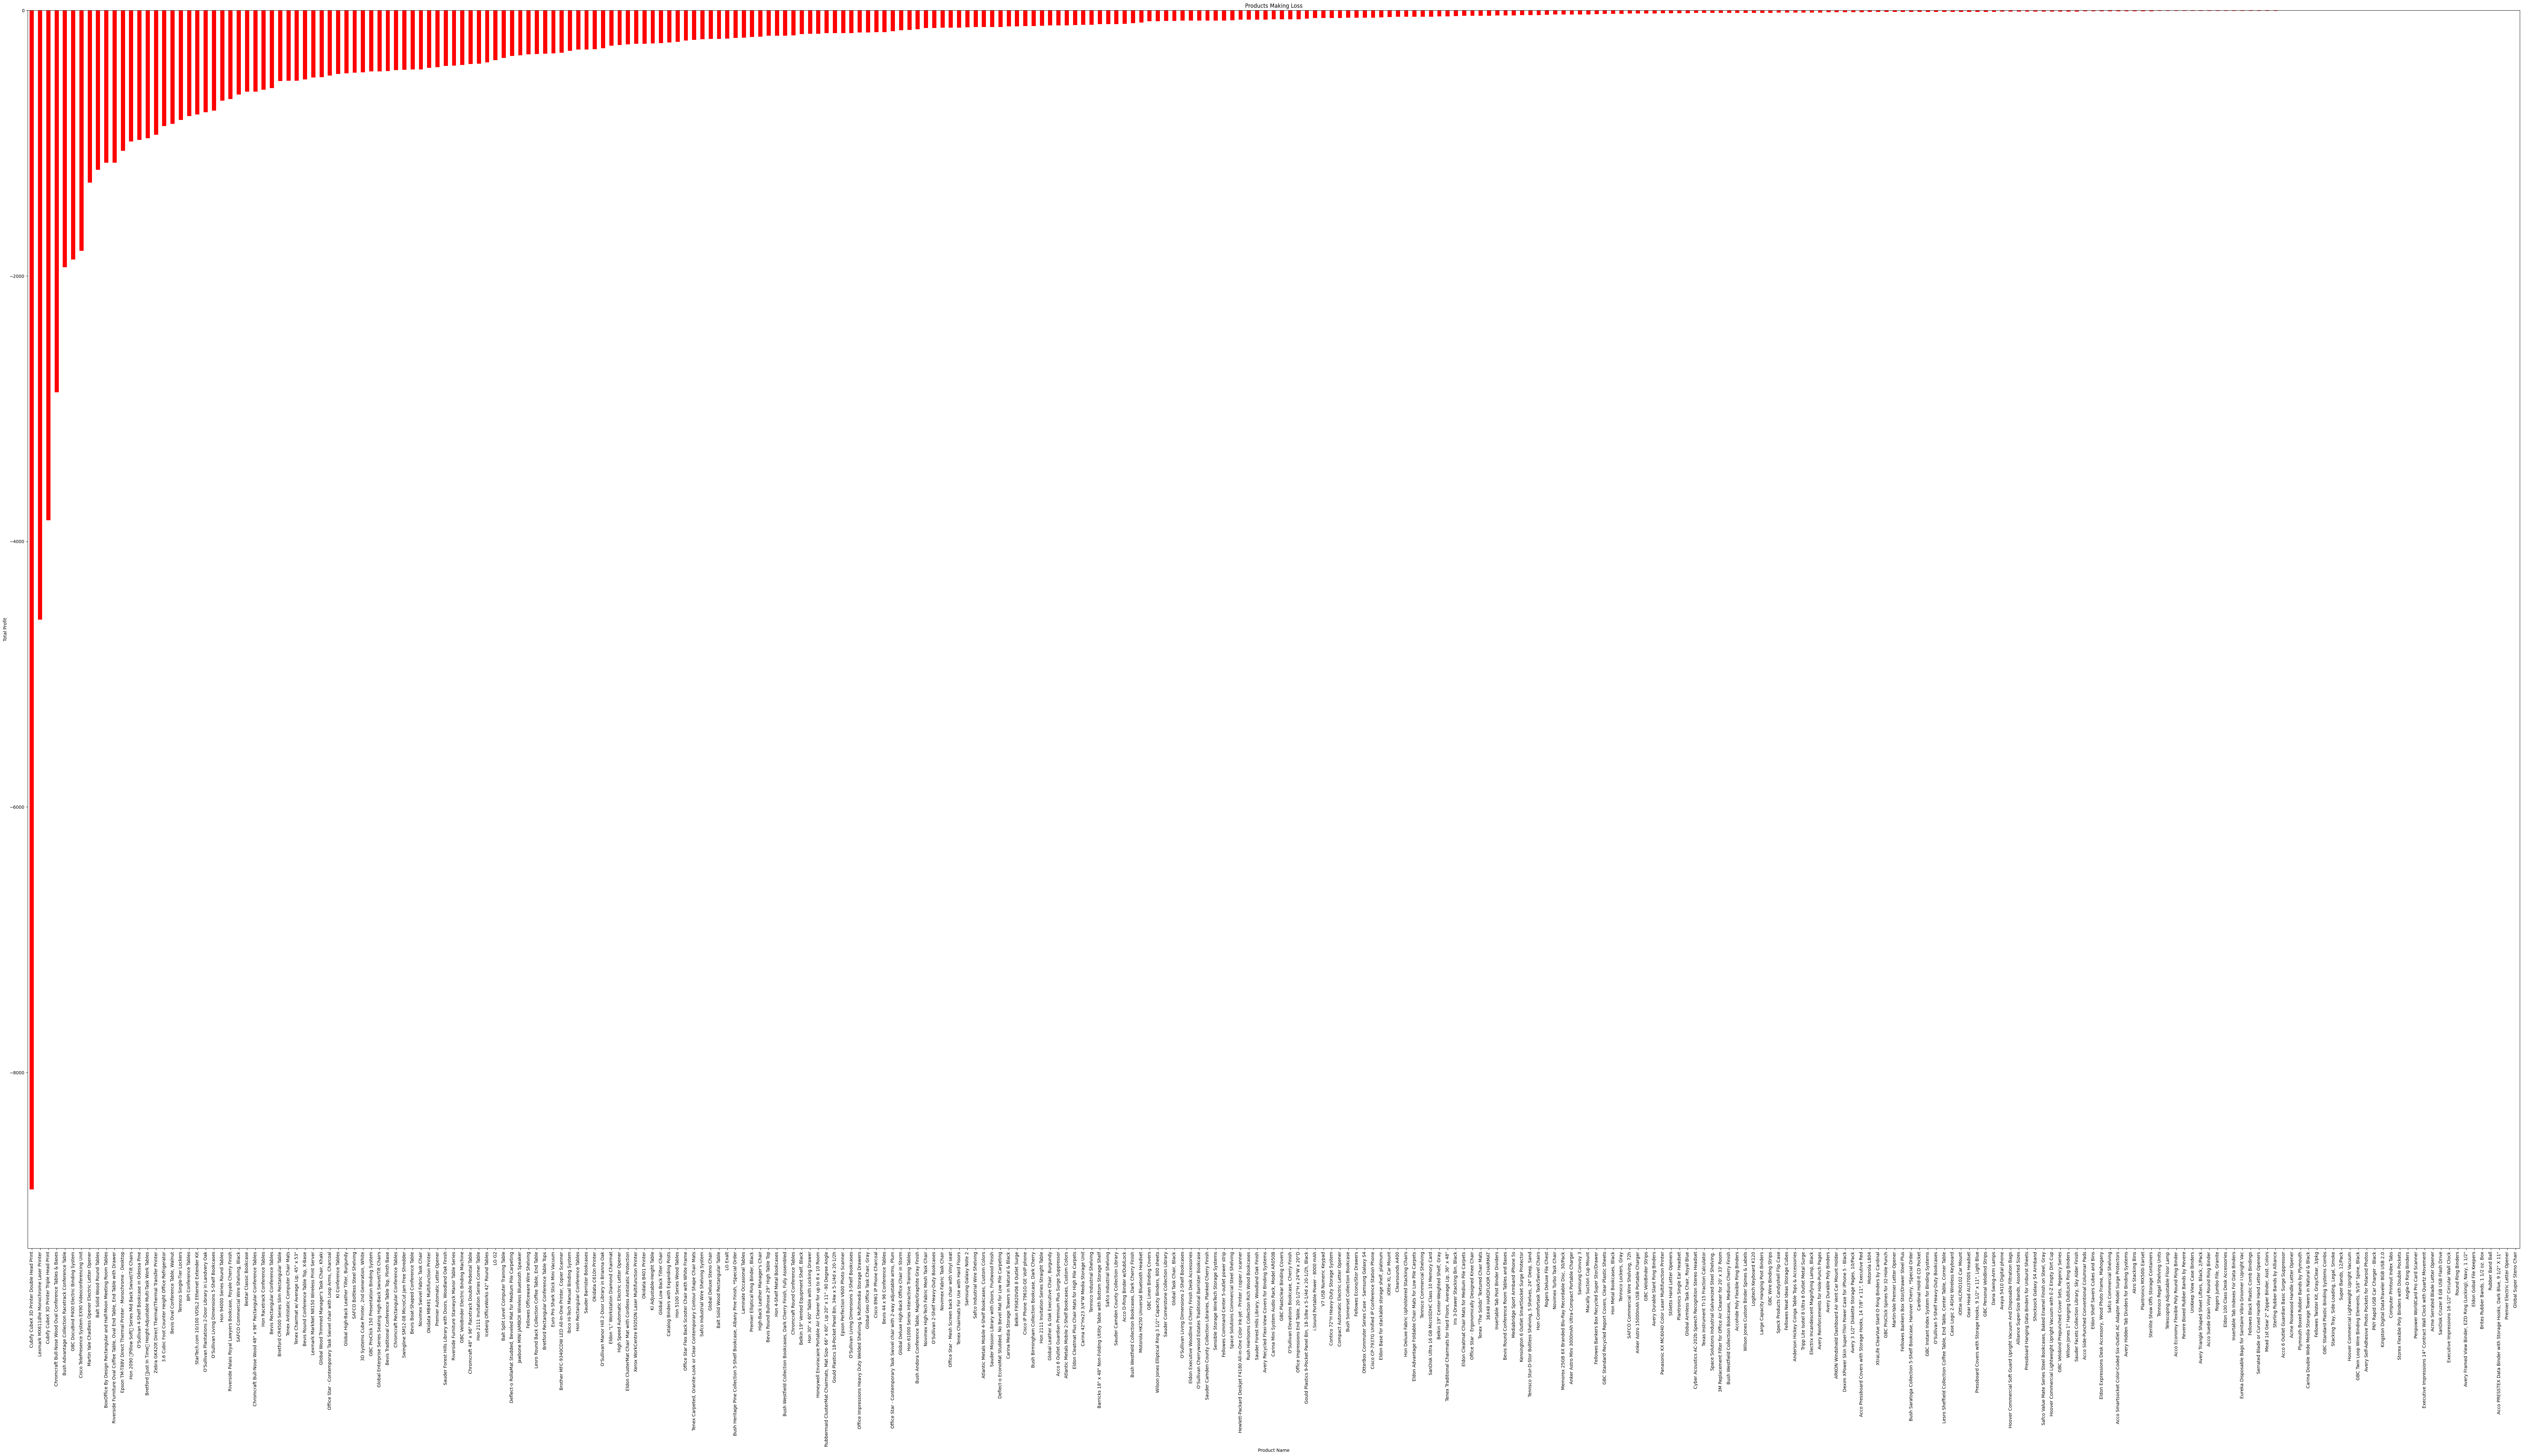

In [ ]:
#visualisation
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 5))
plt.subplot(1, 1, 1)
sns.histplot(data['Profit'], bins=20, kde=True)
plt.axvline(data['Profit'].mean(), color='red', linestyle='--', label='Mean Profit')
plt.title('Profit  Distribution')
plt.xlabel('Profit')
plt.ylabel('Frequency')
plt.show()

# most of the profit are under small profit/small loss, the business is not gaining much money.








#loss
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming your DataFrame is named df
# and it has columns like 'Product Name' and 'Profit'

# Step 1: Group by product and sum the profit
product_profit = data.groupby('Product Name')['Profit'].sum().sort_values()

# Step 2: Show products with loss
loss_products = product_profit[product_profit < 0]
print(loss_products.idxmax())

# Step 3: Plot the loss-making products
plt.figure(figsize=(100,50))
loss_products.plot(kind='bar', color='red')
plt.title('Products Making Loss')
plt.ylabel('Total Profit')
plt.show()




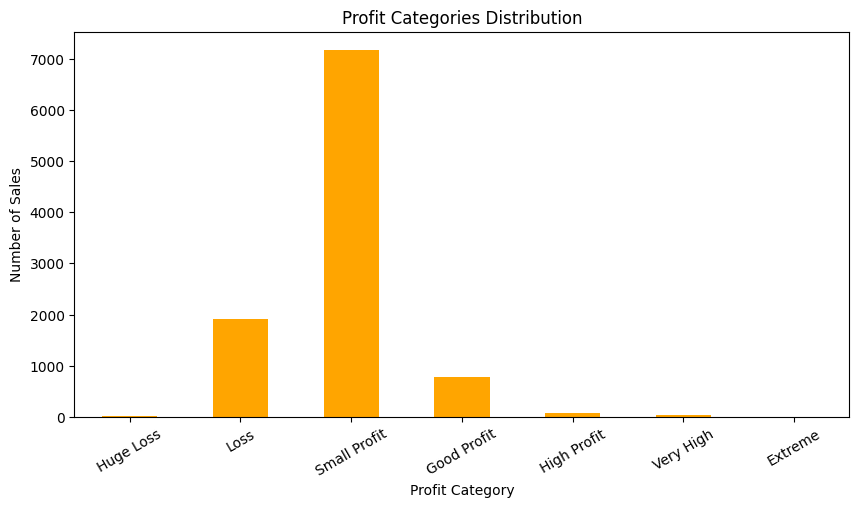

In [ ]:
bins = [-7000, -1000, 0, 100, 500, 1000, 5000, 9000]
labels = ['Huge Loss', 'Loss', 'Small Profit', 'Good Profit', 'High Profit', 'Very High', 'Extreme']
data['Profit Category'] = pd.cut(data['Profit'], bins=bins, labels=labels)

profit_counts = data['Profit Category'].value_counts().sort_index()
profit_counts.plot(kind='bar', color='orange', figsize=(10, 5))
plt.title('Profit Categories Distribution')
plt.xlabel('Profit Category')
plt.ylabel('Number of Sales')
plt.xticks(rotation=30)
plt.show()

# most of my profit fall under 70% so  I should  increase production or just focus on high profit products



In [ ]:
#bestselling category by sales

best_selling_categories=data.groupby('Category')['Sales'].sum()
#idxmax=index of the maximum sum
print(f"best selling category: {best_selling_categories.idxmax()}")

best selling category: Technology


In [ ]:
#most profitable category
most_profitable_category=data.groupby('Category')['Profit'].sum()
print(f"most profitable category: {most_profitable_category.idxmax()}")


#Technology is the most profitable category.Office Supplies has moderate profits.Furniture has the lowest profit — possibly needs reevaluation in pricing or inventory management.

most profitable category: Technology


<Axes: title={'center': 'Monthly Profit Trend'}, xlabel='Order Date'>

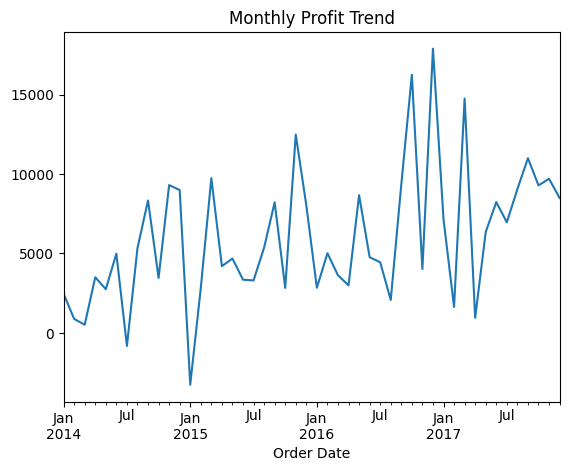

In [ ]:
data['Order Date'] = pd.to_datetime(data['Order Date'], errors='coerce')
monthly_profit = data.groupby(data['Order Date'].dt.to_period('M'))['Profit'].sum()
monthly_profit.plot(kind='line', title='Monthly Profit Trend')


#in the end of the year the sales tend to increase a lot than other months.

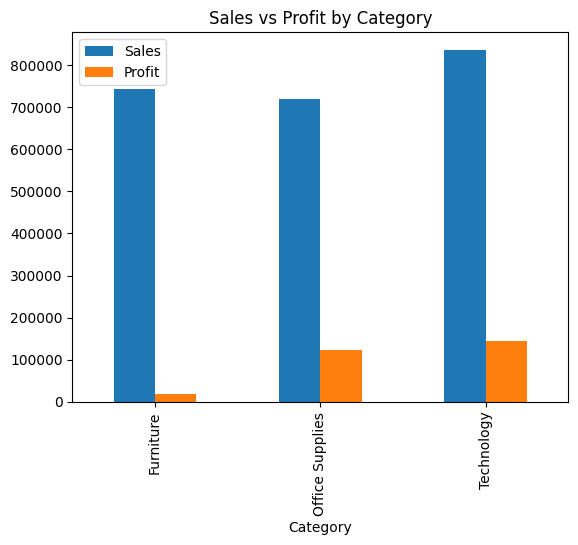

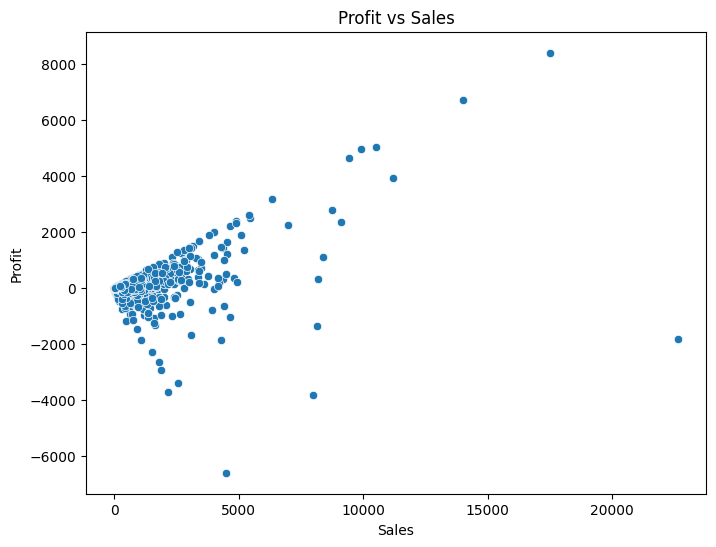

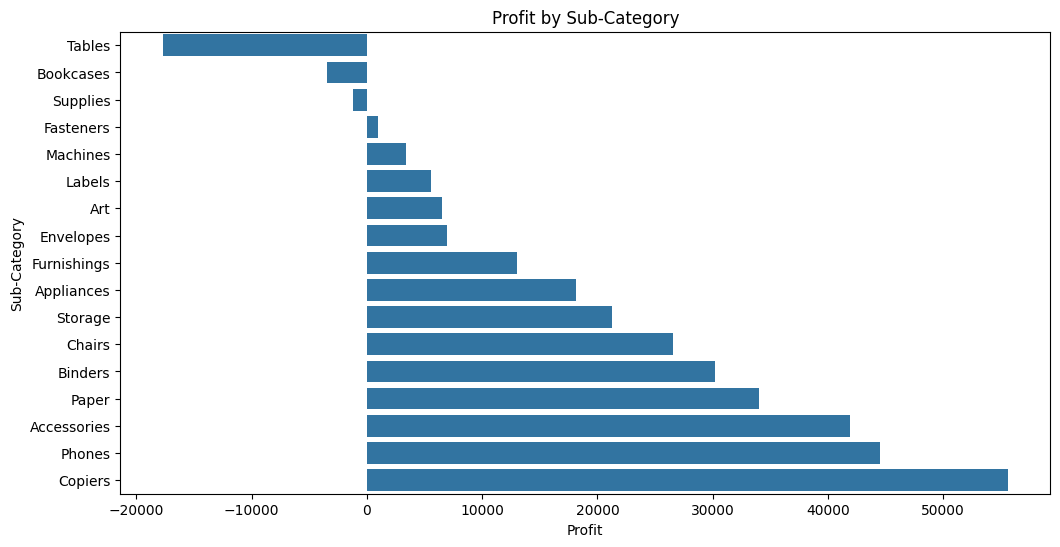

In [ ]:
category_data = data.groupby('Category')[['Sales', 'Profit']].sum()
category_data.plot(kind='bar', title='Sales vs Profit by Category')



#this shows that the sales of furniture is high but profit is low
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(8, 6))
sns.scatterplot(x='Sales', y='Profit', data=data)
plt.title('Profit vs Sales')
plt.xlabel('Sales')
plt.ylabel('Profit')
plt.show()

#profit by subcategory
plt.figure(figsize=(12, 6))
subcategory_profit = data.groupby('Sub-Category')['Profit'].sum().sort_values().reset_index()
sns.barplot(x='Profit', y='Sub-Category', data=subcategory_profit)
plt.title('Profit by Sub-Category')
plt.xlabel('Profit')
plt.ylabel('Sub-Category')
plt.show()


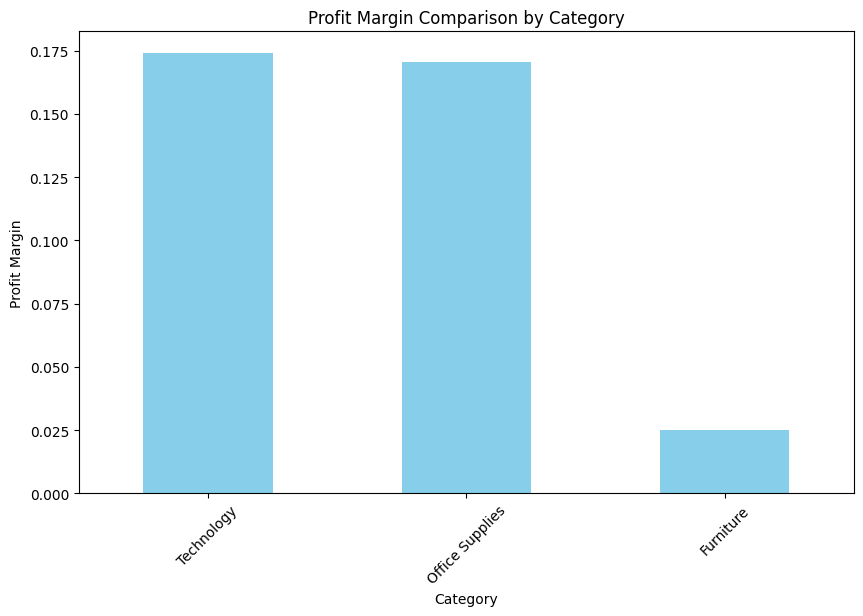

In [ ]:
# Plot Profit Margin per Category

category_sales_profit['Profit Margin'].plot(kind='bar', figsize=(10, 6), color='skyblue')
plt.title('Profit Margin Comparison by Category')
plt.ylabel('Profit Margin')
plt.xlabel('Category')
plt.xticks(rotation=45)
plt.show()


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 23 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Row ID           9994 non-null   int64         
 1   Order ID         9994 non-null   object        
 2   Order Date       9994 non-null   datetime64[ns]
 3   Ship Date        9994 non-null   object        
 4   Ship Mode        9994 non-null   object        
 5   Customer ID      9994 non-null   object        
 6   Customer Name    9994 non-null   object        
 7   Segment          9994 non-null   object        
 8   Country          9994 non-null   object        
 9   City             9994 non-null   object        
 10  State            9994 non-null   object        
 11  Postal Code      9994 non-null   int64         
 12  Region           9994 non-null   object        
 13  Product ID       9994 non-null   object        
 14  Category         9994 non-null   object 

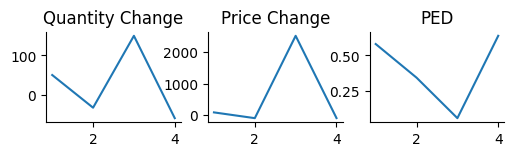

In [ ]:
from matplotlib import pyplot as plt
plt.subplot(3,4,1)
_df_6['Quantity Change'].plot(kind='line', figsize=(8, 4), title='Quantity Change')
plt.gca().spines[['top', 'right']].set_visible(False)

plt.subplot(3,4,2)
_df_7['Price Change'].plot(kind='line', figsize=(8, 4), title='Price Change')
plt.gca().spines[['top', 'right']].set_visible(False)

plt.subplot(3,4,3)
_df_8['PED'].plot(kind='line', figsize=(8, 4), title='PED')
plt.gca().spines[['top', 'right']].set_visible(False)

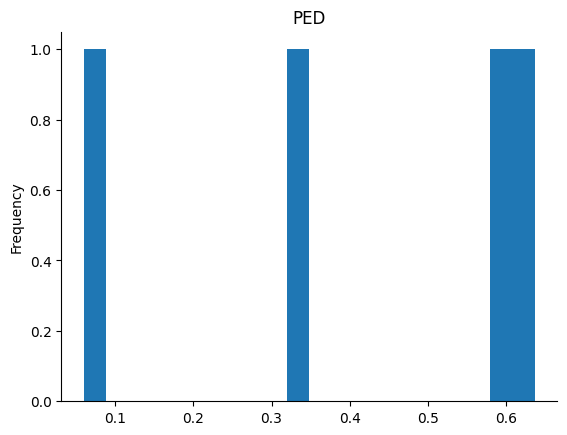

In [ ]:
from matplotlib import pyplot as plt
_df_2['PED'].plot(kind='hist', bins=20, title='PED')
plt.gca().spines[['top', 'right',]].set_visible(False)

State
North Dakota      919.910
West Virginia    1209.824
Maine            1270.530
South Dakota     1315.560
Wyoming          1603.136
Name: Sales, dtype: float64
State
California      457687.6315
New York        310876.2710
Texas           170188.0458
Washington      138641.2700
Pennsylvania    116511.9140
Name: Sales, dtype: float64


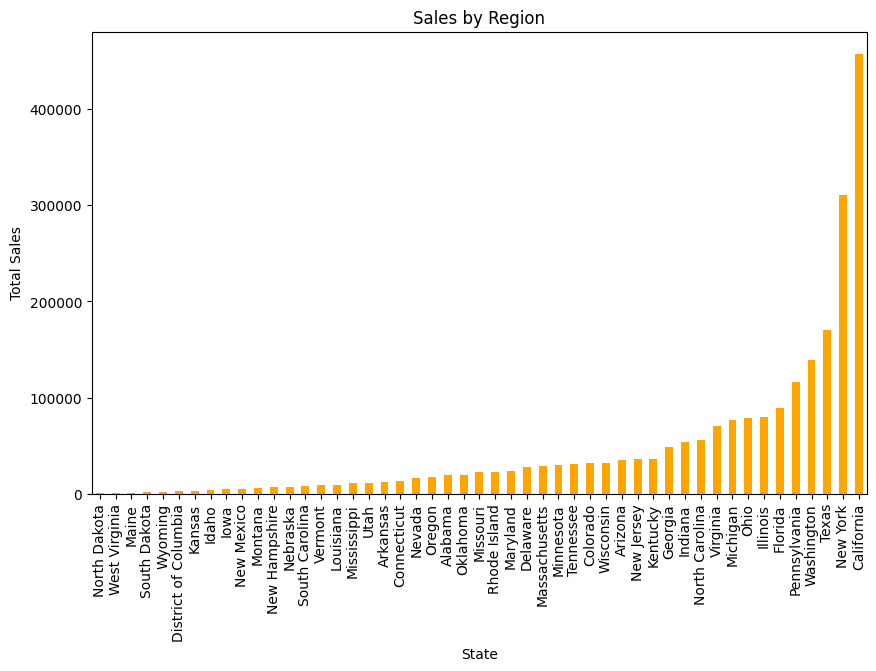

In [ ]:
#loss by region

# Group by city or region and sum the sales
region_sales = data.groupby('State')['Sales'].sum().sort_values()

# Show bottom regions
print(region_sales.head(5))
#show top regions
print(region_sales.tail(5).sort_values(ascending=False))
# Plot
plt.figure(figsize=(10,6))
region_sales.plot(kind='bar', color='orange')
plt.title('Sales by Region')
plt.ylabel('Total Sales')
plt.show()


In [ ]:
import pandas as pd

#High Discount Products and Low Profit
high_discount_products = data[data['Discount'] > 0.3]
 # Products with >30% discount
print("High Discount Products with Low Profit:")
print(high_discount_products[['Product Name', 'Discount', 'Profit']])

# Sales by Region
region_sales = data.groupby('Region')['Sales'].sum()
print("\nSales by Region:")
print(region_sales)

# regions with low sales (e.g., regions in the bottom 25% of sales)
low_sales_regions = region_sales[region_sales < region_sales.quantile(0.25)]  # Lower 25%
print("\nLow-Performing Regions (Lower 25% of Sales):")
print(low_sales_regions)

# Loss-Making Products (Products with negative profit)
loss_making_products = data[data['Profit'] < 0]
print("\nLoss-Making Products:")
print(loss_making_products[['Product Name', 'Profit']])



High Discount Products with Low Profit:
                                           Product Name  Discount     Profit
3         Bretford CR4500 Series Slim Rectangular Table      0.45  -383.0310
14    Holmes Replacement Filter for HEPA Air Cleaner...      0.80  -123.8580
15     Storex DuraTech Recycled Plastic Frosted Binders      0.80    -3.8160
27    Riverside Palais Royal Lawyers Bookcase, Royal...      0.50 -1665.0522
28    Avery Recycled Flexi-View Covers for Binding S...      0.70    -7.0532
...                                                 ...       ...        ...
9899  Chromcraft Bull-Nose Wood Oval Conference Tabl...      0.40  -143.2548
9903  GE General Use Halogen Bulbs, 100 Watts, 1 Bul...      0.60    -6.9102
9920  GBC Pre-Punched Binding Paper, Plastic, White,...      0.80   -35.8176
9921                    Acco Expandable Hanging Binders      0.70    -4.5936
9962  Bush Heritage Pine Collection 5-Shelf Bookcase...      0.32   -67.6704

[1166 rows x 3 columns]

Sales by R

products like "Bretford CR4500 Series Slim Rectangular Table" with a 0.45 discount and a profit of -383.03 are examples of items with high discounts leading to low or negative profits.

Region "South" has the lowest sales with 391,721.91, falling in the bottom 25% of regions.Run targeted marketing campaigns in the South region. Try localized promotions or advertisements.Provide discounts to customers in the South to boost sales.


If the product consistently shows a loss and there’s no significant improvement in demand, consider discontinuing it.Consider rebranding or updating the product to appeal to a new market or customer base.



